# Actividad 1 - Abstraccion en un Campeonato de Futbol

Este notebook muestra como usar abstraccion para modelar un campeonato de futbol.
La idea es definir un contrato comun y permitir implementaciones concretas con reglas distintas.

## Objetivo

1. Definir una clase abstracta para el campeonato.
2. Implementar dos tipos concretos de campeonato.
3. Verificar que ambos cumplen el mismo contrato.

In [2]:
from abc import ABC, abstractmethod


class Campeonato(ABC):
    def __init__(self, nombre: str, temporada: int, equipos_inscritos: int) -> None:
        self.nombre: str = nombre
        self.temporada: int = temporada
        self.equipos_inscritos: int = equipos_inscritos

    @abstractmethod
    def iniciar_competencia(self) -> str:
        """Describe como inicia el campeonato segun su formato."""
        raise NotImplementedError

    @abstractmethod
    def puntos_por_victoria(self) -> int:
        """Regla de puntaje principal de la competencia."""
        raise NotImplementedError

    def resumen(self) -> str:
        return (
            f"{self.nombre} - temporada {self.temporada} - "
            f"{self.equipos_inscritos} equipos"
        )


class LigaUniversitaria(Campeonato):
    def iniciar_competencia(self) -> str:
        return f"{self.nombre}: inicia formato todos contra todos"

    def puntos_por_victoria(self) -> int:
        return 3


class CopaEliminacion(Campeonato):
    def iniciar_competencia(self) -> str:
        return f"{self.nombre}: inicia formato eliminacion directa"

    def puntos_por_victoria(self) -> int:
        return 3

In [4]:
liga = LigaUniversitaria(nombre="Copa Universitaria", temporada=2026, equipos_inscritos=8)
copa = CopaEliminacion(nombre="Copa Ciudad", temporada=2026, equipos_inscritos=16)

print(liga.resumen())
print(liga.iniciar_competencia())
print(copa.resumen())
print(copa.iniciar_competencia())

assert liga.puntos_por_victoria() == 3
assert copa.puntos_por_victoria() == 3
assert "todos contra todos" in liga.iniciar_competencia()
assert "eliminacion directa" in copa.iniciar_competencia()
print("Abstraccion verificada")

Copa Universitaria - temporada 2026 - 8 equipos
Copa Universitaria: inicia formato todos contra todos
Copa Ciudad - temporada 2026 - 16 equipos
Copa Ciudad: inicia formato eliminacion directa
Abstraccion verificada


## Por que aqui usamos abstraccion

- Porque Campeonato define lo esencial que todo torneo debe cumplir.
- Porque permite cambiar el formato sin cambiar el codigo cliente.
- Porque separa el contrato (que hace) de la implementacion (como lo hace).

## Diagrama PlantUML 
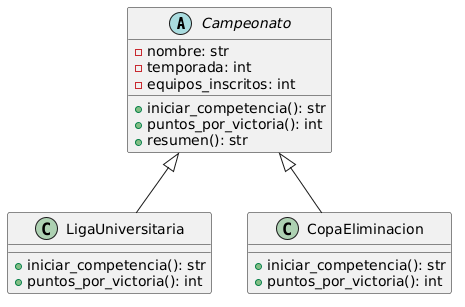